# Olist Delivery Delay Prediction
### Notebook 02: Data Merging
---

**Goal:**  
Combine all 9 cleaned tables into a single analysis-ready dataset  
where **ONE ROW = ONE ORDER**

**Input:** All cleaned tables from Notebook 01  
**Output:** `olist_merged.csv` — ready for EDA

---

### Merge Strategy

| Step | Action |
|------|--------|
| 1 | Aggregate `geolocation` → one median lat/lng per zip code |
| 2 | Enrich `items` with `products` + `translation` + `sellers` → aggregate to order level |
| 3 | Aggregate `payments` → one row per order |
| 4 | Prepare `reviews` → keep one review per order |
| 5 | Build final dataset → LEFT JOIN everything onto `orders` |
| 6 | Drop unnecessary columns |
| 7 | Final quality check |

 All joins are **LEFT JOIN** to preserve all 96,461 orders.

<div align="center">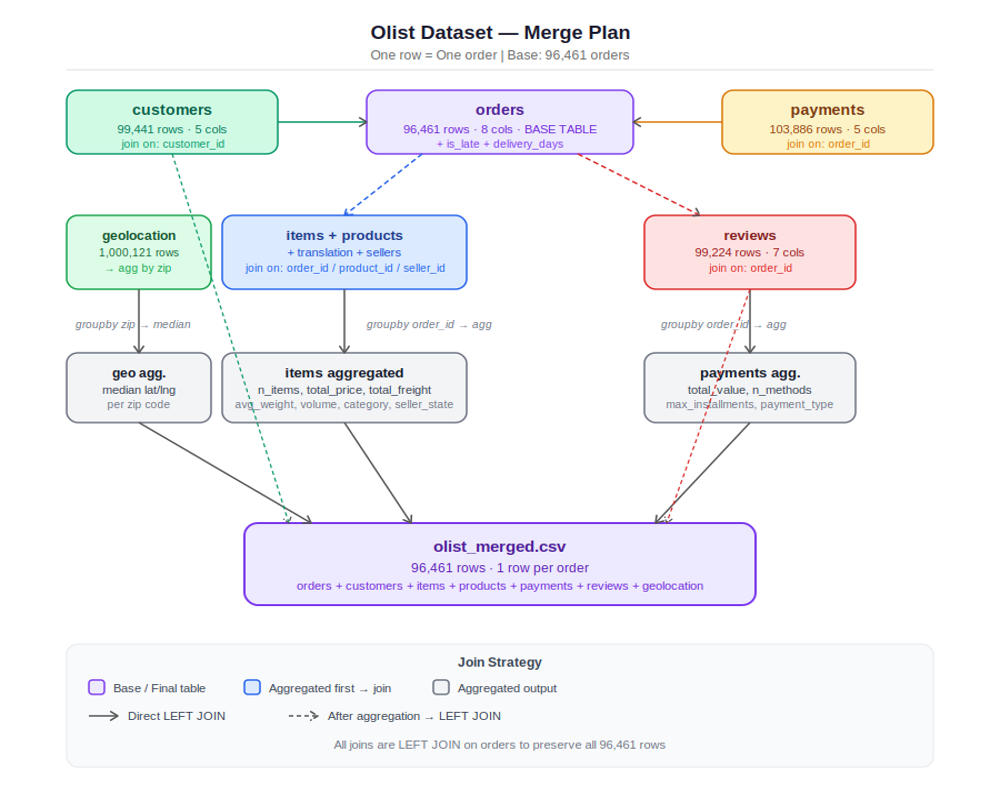<br><p style="color: grey; font-style: italic;">Figure 1: Olist Dataset Merge Strategy</p></div>

##  Load Data

In [1]:
import pandas as pd
import numpy as np

PATH = '../data/processed/'

orders      = pd.read_csv(PATH + 'orders_clean.csv',      parse_dates=['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'])
items       = pd.read_csv(PATH + 'items_clean.csv',       parse_dates=['shipping_limit_date'])
payments    = pd.read_csv(PATH + 'payments_clean.csv')
reviews     = pd.read_csv(PATH + 'reviews_clean.csv',     parse_dates=['review_creation_date', 'review_answer_timestamp'])
customers   = pd.read_csv(PATH + 'customers_clean.csv')
sellers     = pd.read_csv(PATH + 'sellers_clean.csv')
products    = pd.read_csv(PATH + 'products_clean.csv')
geolocation = pd.read_csv(PATH + 'geolocation_clean.csv')
translation = pd.read_csv(PATH + 'translation_clean.csv')

print(f"orders: {len(orders):,} rows | late rate: {orders['is_late'].mean()*100:.1f}%")

orders: 96,461 rows | late rate: 8.1%


---

##  Aggregate Geolocation 

In [2]:
# One zip code has many GPS readings —> take median lat/lng per zip
geo_agg = (
    geolocation
    .groupby('geolocation_zip_code_prefix', as_index=False)
    .agg(lat=('geolocation_lat', 'median'),
         lng=('geolocation_lng', 'median'))
)

print(f"geolocation: {len(geolocation):,} rows → {len(geo_agg):,} unique zip codes")

geolocation: 1,000,121 rows → 19,010 unique zip codes


The geolocation table has **1,000,121 rows** — hundreds of GPS readings per zip code.
We reduced it to **19,010 unique zip codes** by taking the median lat/lng per zip.

This is required before merging — otherwise every order would duplicate thousands of times.
Median is used over mean for robustness against outliers.

 Precision is zip-code level, not exact address | distance features are approximations.

---

## Enrich & Aggregate Items

The items table has **112,650 rows** — multiple items per order.
We need to enrich each item with its product info and seller location,
then collapse everything to **one row per order**.

**Joins performed:**
- `items` + `products` → add weight, dimensions, category (Portuguese)
- `items` + `translation` → translate category to English
- `items` + `sellers` → add seller zip code and state

**Aggregation logic:**
- `n_items` → max of order_item_id (counts items per order)
- `total_price` / `total_freight` → sum
- `avg_product_weight_g` / `avg_product_volume_cm3` → mean
- `product_category` → first (English)
- `seller_zip_code_prefix` / `seller_state` → first

In [3]:
# Add product info, english category, and seller location to each item
items_enriched = items.merge(products, on='product_id', how='left')
items_enriched = items_enriched.merge(translation, on='product_category_name', how='left')
items_enriched = items_enriched.merge(
    sellers[['seller_id', 'seller_zip_code_prefix', 'seller_state']],
    on='seller_id', how='left'
)

# Calculate product volume
items_enriched['product_volume_cm3'] = (
    items_enriched['product_length_cm'] *
    items_enriched['product_height_cm'] *
    items_enriched['product_width_cm']
)

# Collapse to one row per order
items_agg = (
    items_enriched
    .groupby('order_id', as_index=False)
    .agg(
        n_items                = ('order_item_id',                 'max'),
        n_unique_sellers       = ('seller_id',                     'nunique'),
        total_price            = ('price',                         'sum'),
        total_freight          = ('freight_value',                 'sum'),
        avg_product_weight_g   = ('product_weight_g',              'mean'),
        avg_product_volume_cm3 = ('product_volume_cm3',            'mean'),
        product_category       = ('product_category_name_english', 'first'),
        seller_zip_code_prefix = ('seller_zip_code_prefix',        'first'),
        seller_state           = ('seller_state',                  'first'),
    )
)

print(f"items: {len(items):,} rows → {len(items_agg):,} orders")
print(f"columns added: {list(items_agg.columns[1:])}")

items: 112,650 rows → 98,666 orders
columns added: ['n_items', 'n_unique_sellers', 'total_price', 'total_freight', 'avg_product_weight_g', 'avg_product_volume_cm3', 'product_category', 'seller_zip_code_prefix', 'seller_state']


 **Note:** items_agg contains **98,666 orders** while orders has **96,461**.

 The difference (~2,200 orders) were dropped in Notebook 01 due to incomplete delivery cycles.
 
  The LEFT JOIN on orders will handle this automatically, only the 96,461 clean orders will be kept.

---

## Aggregate Payments

The payments table has **103,886 rows** — some orders were paid
using more than one payment method.
We collapse to **one row per order**.

In [4]:
# Some orders have multiple payment methods —> aggregate to one row per order
payments_agg = (
    payments
    .groupby('order_id', as_index=False)
    .agg(
        total_payment_value = ('payment_value',        'sum'),
        n_payment_methods   = ('payment_sequential',   'max'),
        max_installments    = ('payment_installments', 'max'),
        payment_type        = ('payment_type',         lambda x: x.mode()[0])
    )
)

print(f"payments: {len(payments):,} rows → {len(payments_agg):,} orders")

payments: 103,886 rows → 99,440 orders


 **Note:** payments_agg contains **99,440 orders** while orders has **96,461**.

 Same reason as items —> incomplete orders were dropped in Notebook 01.

 The LEFT JOIN on orders will keep only the 96,461 clean orders.

---

## Prepare Reviews

We keep only `review_score` —> the objective satisfaction measure.
Comment text requires NLP and will be handled in Feature Engineering.

One review per order —> drop duplicates to be safe.

In [5]:
# Keep one review per order, score only
reviews_clean = (
    reviews
    .drop_duplicates(subset='order_id', keep='first')
    [['order_id', 'review_score']]
)

print(f"reviews: {len(reviews):,} rows → {len(reviews_clean):,} unique orders")

reviews: 99,224 rows → 98,673 unique orders


 **Note:** reviews_clean contains **98,673 orders** while orders has **96,461**.

 The LEFT JOIN on orders  will keep only the 96,461 clean orders.
 
 Some orders may also have no review —> these will appear as NaN in review_score.

---

## Build Final Dataset

Start with `orders` as the base table and LEFT JOIN everything onto it.
LEFT JOIN ensures all 96,461 orders are preserved even if a match is missing.

In [6]:
df = orders.copy()

# customers → zip code + state
df = df.merge(
    customers[['customer_id', 'customer_unique_id',
               'customer_zip_code_prefix', 'customer_state']],
    on='customer_id', how='left'
)

# items aggregation
df = df.merge(items_agg, on='order_id', how='left')

# payments aggregation
df = df.merge(payments_agg, on='order_id', how='left')

# reviews
df = df.merge(reviews_clean, on='order_id', how='left')

# customer coordinates
df = df.merge(
    geo_agg.rename(columns={
        'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
        'lat': 'customer_lat',
        'lng': 'customer_lng'
    }),
    on='customer_zip_code_prefix', how='left'
)

# seller coordinates
df = df.merge(
    geo_agg.rename(columns={
        'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
        'lat': 'seller_lat',
        'lng': 'seller_lng'
    }),
    on='seller_zip_code_prefix', how='left'
)

print(f"shape after each join:")
print(f"  final shape: {df.shape}")

shape after each join:
  final shape: (96461, 31)


 **Result:** Final shape **(96,461 rows × 31 columns)** —> all orders preserved.
 
 All LEFT JOINs worked correctly, no row duplication or loss.

---

## Drop Unnecessary Columns

Remove columns that are redundant or no longer needed after merging.

In [7]:
cols_to_drop = [
    'customer_id',  # replaced by customer_unique_id
]

df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Dropped: {cols_to_drop}")
print(f"Final shape: {df.shape}")
print(f"\nColumns ({df.shape[1]} total):")
for col in df.columns:
    print(f"  - {col}")

Dropped: ['customer_id']
Final shape: (96461, 30)

Columns (30 total):
  - order_id
  - order_status
  - order_purchase_timestamp
  - order_approved_at
  - order_delivered_carrier_date
  - order_delivered_customer_date
  - order_estimated_delivery_date
  - is_late
  - delivery_days
  - customer_unique_id
  - customer_zip_code_prefix
  - customer_state
  - n_items
  - n_unique_sellers
  - total_price
  - total_freight
  - avg_product_weight_g
  - avg_product_volume_cm3
  - product_category
  - seller_zip_code_prefix
  - seller_state
  - total_payment_value
  - n_payment_methods
  - max_installments
  - payment_type
  - review_score
  - customer_lat
  - customer_lng
  - seller_lat
  - seller_lng


 **Note:** `product_category_name` (Portuguese) was not added to the final df

 it was already replaced by `product_category` (English) during STEP : aggregation.
 
 No need to drop it here.

---

## Final Quality Check

Verify the merged dataset is clean and ready for EDA.

In [8]:
# Row count
print(f"Rows    : {len(df):,} — {'✓' if len(df) == 96461 else '✗'}")

Rows    : 96,461 — ✓


In [9]:
# Duplicates
print(f"Dupes   : {df['order_id'].duplicated().sum()} — {'✓' if df['order_id'].duplicated().sum() == 0 else '✗'}")

Dupes   : 0 — ✓


In [10]:
# Target
print(f"is_late : {df['is_late'].mean()*100:.1f}% late")

is_late : 8.1% late


- **Target:** 8.1% late orders (7,826) — class imbalance to handle in modeling


In [11]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"\nMissing values:")
print(missing if len(missing) > 0 else "None ✓")


Missing values:
product_category          1351
review_score               646
customer_lat               265
customer_lng               265
seller_lat                 215
seller_lng                 215
avg_product_weight_g        16
avg_product_volume_cm3      16
total_payment_value          1
n_payment_methods            1
max_installments             1
payment_type                 1
dtype: int64


## Missing Values After Merge

| Column | Missing | Reason | Action |
|--------|---------|--------|--------|
| `product_category` | 1,351 | `'unknown'` products have no English translation | Fix → fillna('unknown') after translation join |
| `review_score` | 646 | Not all orders receive a review | Expected —> flag for EDA |
| `customer_lat/lng` | 265 | Customer zip codes missing from geolocation table | Data coverage issue —> flag for EDA |
| `seller_lat/lng` | 215 | Seller zip codes missing from geolocation table | Data coverage issue —> flag for EDA |
| `avg_product_weight_g/volume` | 16 | Product IDs missing from products table | Data coverage issue —> flag for EDA |
| `payment_*` | 1 | One order has no payment record | Data coverage issue —> flag for EDA |

 **Only `product_category` requires a fix**  

 All other missing values are expected and will be handled during Feature Engineering.

In [12]:
# Fix: 'unknown' products have no English translation
df['product_category'] = df['product_category'].fillna('unknown')

# Verify
print(f"product_category missing: {df['product_category'].isnull().sum()} ✓")

product_category missing: 0 ✓


---

## Final Dataset Inspection

Before saving, we take a final look at the dataset to verify:

- Shape and column types are correct

- Data distributions look reasonable

- No unexpected values

In [13]:
# Shape
print(f"Shape: {df.shape}")

# Sample
df.head()

Shape: (96461, 30)


,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_late,delivery_days,customer_unique_id,...,seller_state,total_payment_value,n_payment_methods,max_installments,payment_type,review_score,customer_lat,customer_lng,seller_lat,seller_lng
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0,8,7c396fd4830fd04220f754e42b4e5bff,...,SP,38.71,3.0,1.0,voucher,4.0,-23.576170,-46.587276,-23.681180,-46.444127
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,0,13,af07308b275d755c9edb36a90c618231,...,SP,141.46,1.0,1.0,boleto,4.0,-12.126651,-45.008162,-19.807013,-43.980966
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0,9,3a653a41f6f9fc3d2a113cf8398680e8,...,SP,179.12,1.0,3.0,credit_card,5.0,-16.744472,-48.514624,-21.364020,-48.228831
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0,13,7c142cf63193a1473d2e66489a9ae977,...,MG,72.20,1.0,1.0,credit_card,5.0,-5.774611,-35.273916,-19.836541,-43.921855
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,0,2,72632f0f9dd73dfee390c9b22eb56dd6,...,SP,28.62,1.0,1.0,credit_card,5.0,-23.675316,-46.515116,-23.545033,-46.261847


In [14]:
# Data types
df.dtypes

order_id                                 object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
is_late                                   int64
delivery_days                             int64
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_state                           object
n_items                                   int64
n_unique_sellers                          int64
total_price                             float64
total_freight                           float64
avg_product_weight_g                    float64
avg_product_volume_cm3                  float64
product_category                         object
seller_zip_code_prefix                    int64
seller_state                            

In [15]:
# Statistical summary
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_late,delivery_days,customer_zip_code_prefix,n_items,n_unique_sellers,...,avg_product_volume_cm3,seller_zip_code_prefix,total_payment_value,n_payment_methods,max_installments,review_score,customer_lat,customer_lng,seller_lat,seller_lng
count,96461,96461,96461,96461,96461,96461.000000,96461.000000,96461.000000,96461.000000,96461.000000,...,96445.000000,96461.000000,96460.000000,96460.000000,96460.000000,95815.000000,96196.000000,96196.000000,96246.000000,96246.000000
mean,2018-01-01 23:53:26.642249216,2018-01-02 10:10:06.480142336,2018-01-05 05:21:04.508827392,2018-01-14 13:17:13.228102400,2018-01-25 17:33:14.236012544,0.081131,12.093582,35198.925825,1.142223,1.013902,...,15151.882340,24647.181586,159.855721,1.045169,2.928312,4.156092,-21.205899,-46.189991,-22.795619,-47.224672
min,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,0.000000,0.000000,1003.000000,1.000000,1.000000,...,168.000000,1001.000000,9.590000,1.000000,0.000000,1.000000,-33.690972,-72.670987,-32.074657,-63.893145
25%,2017-09-14 09:28:28,2017-09-14 14:30:14,2017-09-18 16:52:19,2017-09-25 22:31:59,2017-10-05 00:00:00,0.000000,6.000000,11355.000000,1.000000,1.000000,...,2816.000000,6429.000000,61.880000,1.000000,1.000000,4.000000,-23.590133,-48.119474,-23.613259,-48.805319
50%,2018-01-20 19:59:42,2018-01-22 13:49:00,2018-01-24 16:19:03,2018-02-02 19:50:56,2018-02-16 00:00:00,0.000000,10.000000,24436.000000,1.000000,1.000000,...,6400.000000,13566.000000,105.280000,1.000000,2.000000,5.000000,-22.925419,-46.632664,-23.424399,-46.753494
75%,2018-05-05 18:33:24,2018-05-06 10:30:49,2018-05-08 14:33:00,2018-05-15 23:08:54,2018-05-28 00:00:00,0.000000,15.000000,59056.000000,1.000000,1.000000,...,18228.000000,29156.000000,176.330000,1.000000,4.000000,5.000000,-20.140685,-43.629386,-21.757690,-46.520229
max,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,1.000000,209.000000,99980.000000,21.000000,5.000000,...,296208.000000,99730.000000,13664.080000,26.000000,24.000000,5.000000,3.844931,-34.799347,-2.498944,-34.855123
std,NaN,NaN,NaN,NaN,NaN,0.273038,9.551576,29839.654761,0.538848,0.123547,...,23216.236929,27728.375695,218.828474,0.370685,2.712842,1.284687,5.589334,4.050397,2.756706,2.350697


- **delivery_days:** ranges from 0 to 209 —> outliers retained intentionally (Notebook 01)
- **n_payment_methods / max_installments:** float64 due to 1 missing value —> fix this
- **Coordinates:** lat/lng available for ~99.7% of orders —> sufficient for distance features
- **review_score:** missing for 646 orders (~0.7%) —> expected, not all orders receive a review



---

## Fix: Payment Columns

One order has no payment record in the payments table.
After LEFT JOIN all payment columns became NaN.
pandas converted int columns to float64 because int cannot hold NaN.

**Fix applied:**
- `total_payment_value` → fillna(0.0) — float is correct for prices
- `n_payment_methods` → fillna(0) + cast to int — count must be int
- `max_installments` → fillna(0) + cast to int — count must be int  
- `payment_type` → fillna('unknown')

Order is kept because it has valid delivery data and is_late value.

In [19]:
df['n_payment_methods'] = df['n_payment_methods'].fillna(0).astype(int)
df['max_installments']  = df['max_installments'].fillna(0).astype(int)
df['total_payment_value'] = df['total_payment_value'].fillna(0.0)
df['payment_type'] = df['payment_type'].fillna('unknown')

print(df[['total_payment_value', 'n_payment_methods', 'max_installments', 'payment_type']].dtypes)

total_payment_value    float64
n_payment_methods        int32
max_installments         int32
payment_type            object
dtype: object


In [22]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing if len(missing) > 0 else "None ✓")

review_score              646
customer_lat              265
customer_lng              265
seller_lat                215
seller_lng                215
avg_product_weight_g       16
avg_product_volume_cm3     16
dtype: int64


In [21]:
# Find product_ids that exist in items but not in products
missing_product_ids = items[~items['product_id'].isin(products['product_id'])]['product_id'].unique()

print(f"Missing product_ids: {len(missing_product_ids)}")
print(f"IDs: {missing_product_ids}")

# How many orders are affected?
affected = items[items['product_id'].isin(missing_product_ids)]
print(f"\nAffected orders : {affected['order_id'].nunique()}")
print(f"Affected items  : {len(affected)}")

Missing product_ids: 2
IDs: ['5eb564652db742ff8f28759cd8d2652a' '09ff539a621711667c43eba6a3bd8466']

Affected orders : 16
Affected items  : 18


 **Verified:** 2 product_ids exist in items but are missing from products table.
 
 - product_id: `5eb564652db742ff8f28759cd8d2652a`
 - product_id: `09ff539a621711667c43eba6a3bd8466`

 These 2 products appear in 18 items across 16 different orders.

 Result: `avg_product_weight_g` and `avg_product_volume_cm3` = NaN for these 16 orders.

---

### Understanding the Remaining Missing Values

Where did they come from?

* review_score → 646
Not every customer fills out the satisfaction survey after delivery.
These orders simply have no review, completely normal.

* customer_lat/lng → 265
Customer zip codes that exist in the orders table but are not found in the geolocation table.
The geolocation table doesn't cover 100% of Brazilian zip codes.

* seller_lat/lng → 215
Same reason — seller zip codes missing from the geolocation table.

* avg_product_weight_g / avg_product_volume_cm3 → 16

   2 product_ids exist in the items table but are missing from the products table.
   
   These 2 products appear across 16 orders → weight and volume = NaN.

----

## Important Notes

The following columns have missing values that require informed decisions
based on EDA findings — do not fill blindly:

- `review_score` (646 missing)
  → Option 1: fill with median
  → Option 2: create binary flag `has_review` (1/0)

- `customer_lat/lng` (265 missing) / `seller_lat/lng` (215 missing)
  → Option 1: drop these rows when calculating distance feature
  → Option 2: fill with state-level median coordinates

- `avg_product_weight_g` / `avg_product_volume_cm3` (16 missing)
  → Option 1: fill with median per product category
  → Option 2: flag as missing with binary column


In [23]:
# Binary flag: did the customer leave a review?
df['has_review'] = df['review_score'].notna().astype(int)

print(df['has_review'].value_counts())

has_review
1    95815
0      646
Name: count, dtype: int64


> **Added:** `has_review` binary flag (1 = has review, 0 = no review)
> 95,815 orders have a review (99.3%) — 646 do not (0.7%)

---

In [24]:
# Fill weight and volume with median, 16 rows
median_weight = df['avg_product_weight_g'].median()
median_volume = df['avg_product_volume_cm3'].median()

df['avg_product_weight_g']   = df['avg_product_weight_g'].fillna(median_weight)
df['avg_product_volume_cm3'] = df['avg_product_volume_cm3'].fillna(median_volume)

print(f"avg_product_weight_g  missing: {df['avg_product_weight_g'].isnull().sum()}")
print(f"avg_product_volume_cm3 missing: {df['avg_product_volume_cm3'].isnull().sum()}")

avg_product_weight_g  missing: 0
avg_product_volume_cm3 missing: 0


---

 **Why `customer_lat/lng` and `seller_lat/lng` are deferred:**

 Brazil's states are geographically large, filling with state-level median
 would place customers/sellers at the center of the state, far from their
 actual city.

 This would produce incorrect distance calculations.
 The correct approach depends on how coordinates will be used in the model,
 
 which will be decided after EDA.

---

## Unique Values Inspection

In [25]:
for col in df.columns:
    n_unique = df[col].nunique()
    print(f"\n{col} — {n_unique} unique values")
    if n_unique <= 10:
        print(df[col].value_counts())


order_id — 96461 unique values

order_status — 2 unique values
order_status
delivered    96455
canceled         6
Name: count, dtype: int64

order_purchase_timestamp — 95939 unique values

order_approved_at — 88272 unique values

order_delivered_carrier_date — 80100 unique values

order_delivered_customer_date — 95649 unique values

order_estimated_delivery_date — 445 unique values

is_late — 2 unique values
is_late
0    88635
1     7826
Name: count, dtype: int64

delivery_days — 146 unique values

customer_unique_id — 93342 unique values

customer_zip_code_prefix — 14889 unique values

customer_state — 27 unique values

n_items — 17 unique values

n_unique_sellers — 5 unique values
n_unique_sellers
1    95186
2     1216
3       54
4        3
5        2
Name: count, dtype: int64

total_price — 7636 unique values

total_freight — 7877 unique values

avg_product_weight_g — 2766 unique values

avg_product_volume_cm3 — 5809 unique values

product_category — 72 unique values

seller_zip_co

## Unique Values Inspection — Key Observations

**Requires investigation:**
- `order_status` → 6 canceled orders found. should have been removed in Notebook 01
- `n_payment_methods` → max = 20. unusually high, needs verification

**Expected and valid:**
- `is_late` → 8.1% late (7,826 orders) — confirmed class imbalance
- `payment_type` → credit_card dominates (76.7%) — typical for Brazilian e-commerce
- `review_score` → majority 5 stars — positive skew expected
- `n_unique_sellers` → 98.7% of orders have only 1 seller — expected
- `has_review` → 99.3% of orders have a review — good coverage
- `product_category` → 72 categories including 'unknown'
- `customer_state` → 27 states — full Brazil coverage
- `seller_state` → 22 states — sellers concentrated in fewer states

In [26]:
# Inspect the 6 canceled orders
canceled = df[df['order_status'] == 'canceled']
print(f"Canceled orders: {len(canceled)}")
print(canceled[['order_id', 'order_status', 'is_late', 'delivery_days', 
                'order_delivered_customer_date']].to_string())

Canceled orders: 6
                               order_id order_status  is_late  delivery_days order_delivered_customer_date
2843   1950d777989f6a877539f53795b4c3c3     canceled        1             30           2018-03-21 22:03:51
8545   dabf2b0e35b423f94618bf965fcb7514     canceled        0              7           2016-10-16 14:36:59
56529  770d331c84e5b214bd9dc70a10b829d0     canceled        0              7           2016-10-14 15:07:11
57557  8beb59392e21af5eb9547ae1a9938d06     canceled        0             10           2016-10-19 18:47:43
89861  65d1e226dfaeb8cdc42f665422522d14     canceled        0             35           2016-11-08 10:58:34
91573  2c45c33d2f9cb8ff8b1c86cc28c11c30     canceled        0             30           2016-11-09 14:53:50


## Fix: Canceled Orders

**Finding:**
6 orders with `order_status = canceled` were found in the dataset.
These orders have a `order_delivered_customer_date` and `is_late` value,
which is why they were not removed in Notebook 01 (filter was based on
missing timestamps, not on order status).

**Decision:**
Remove these 6 orders — a canceled order cannot have a valid delivery date.
This is a data inconsistency in the raw data.

**Impact:** 96,461 → 96,455 orders

In [27]:
# Remove the 6 canceled orders
df = df[df['order_status'] != 'canceled']
print(f"Rows after removing canceled: {len(df):,}")

Rows after removing canceled: 96,455


---

In [28]:
print(df['n_payment_methods'].value_counts().sort_index())

n_payment_methods
0         1
1     93503
2      2387
3       297
4       104
5        52
6        35
7        28
8        10
9         7
10        3
11        8
12        8
13        3
14        2
15        2
19        2
21        1
22        1
26        1
Name: count, dtype: int64


In [29]:
# Inspect orders with unusually high payment methods
high_payments = df[df['n_payment_methods'] > 10]
print(f"Orders with >10 payment methods: {len(high_payments)}")
print(high_payments[['order_id', 'n_payment_methods', 'total_payment_value', 'payment_type']].to_string())

Orders with >10 payment methods: 28
                               order_id  n_payment_methods  total_payment_value payment_type
7474   285c2e15bebd4ac83635ccc563dc71f4                 22                40.85      voucher
9136   27a940efdd448db29463b53ea0cfa2f4                 11                87.66      voucher
9143   4069c489933782af79afcd3a0e4d693c                 11               147.15      voucher
16865  21577126c19bf11a0b91592e5844ba78                 15                86.99      voucher
17046  654da57158d96035814657b5143bb11b                 11               317.80      voucher
17833  1a611328643ae11146ba09a4425d2e12                 12                69.97      voucher
22256  4bfcba9e084f46c8e3cb49b0fa6e6159                 15               740.76      voucher
26264  fedcd9f7ccdc8cba3a18defedd1a5547                 19               205.74      voucher
27622  67d83bd36ec2c7fb557742fb58837659                 12                72.17      voucher
29249  0bbb3f7791a87d0307555e57da3

## Note: High n_payment_methods

28 orders have more than 10 payment methods — all are `voucher` type.
This is expected behavior in Olist:
each voucher/coupon is recorded as a separate payment sequential entry.
An order with 26 vouchers simply used 26 different coupons.
This is not a data error.

---

In [30]:
# Save the final dataset
df.to_csv('../data/processed/olist_merged.csv', index=False)
print(f"✓ Saved: olist_merged.csv")
print(f"  Shape : {df.shape}")

✓ Saved: olist_merged.csv
  Shape : (96455, 31)


---

## Merging Summary

**Input:** 9 cleaned tables from Notebook 01  
**Output:** `olist_merged.csv` — 96,455 rows × 31 columns

---

### Steps Performed

| Step | Action | Result |
|------|--------|--------|
| 1 | Aggregate geolocation by zip code (median lat/lng) | 1,000,121 → 19,010 unique zip codes |
| 2 | Enrich items with products + translation + sellers → aggregate to order level | 112,650 → 98,666 orders |
| 3 | Aggregate payments → one row per order | 103,886 → 99,440 orders |
| 4 | Prepare reviews → one review per order | 99,224 → 98,673 orders |
| 5 | LEFT JOIN everything onto orders | 96,461 rows × 31 columns |
| 6 | Drop `customer_id` (replaced by `customer_unique_id`) | 31 → 30 columns |
| 7 | Quality check + fixes | 96,455 rows × 31 columns |

---

### Fixes Applied

| Issue | Fix |
|-------|-----|
| `product_category` NaN after translation join | fillna('unknown') |
| Payment columns NaN (1 order with no payment record) | fillna(0) + cast to correct dtypes |
| `avg_product_weight_g/volume` NaN (2 missing product_ids) | fillna(median) |
| 6 canceled orders with delivery dates | Removed |
| Added `has_review` binary flag | 1 = has review, 0 = no review |

---

### Remaining Missing Values

| Column | Missing | Reason | Handled In |
|--------|---------|--------|------------|
| `review_score` | 646 | Customer did not submit a review | Feature Engineering |
| `customer_lat/lng` | 265 | Zip code not in geolocation table | Feature Engineering |
| `seller_lat/lng` | 215 | Zip code not in geolocation table | Feature Engineering |

---

### Final Dataset

- **Shape:** 96,455 rows × 31 columns
- **Target:** `is_late` — 8.1% late (7,826 orders)
- **Ready for:** `03_EDA.ipynb`